In [78]:
import torch
import matplotlib.pyplot as plt
from math import floor, ceil

In [79]:
torch.manual_seed(42)

### Setting the Data

In [81]:
NUMBER_OF_DATA_POINTS = 10
X_RANGE = {
    'min': 0,
    'max': 2
}
SLOPE = 3
INTERCEPT = 4
NOISE_RANGE = 1.5
m = NUMBER_OF_DATA_POINTS  # the number of instances

def generate_data(
    x_range:dict[str, str]=X_RANGE,
    number_of_data_points:int=NUMBER_OF_DATA_POINTS,
    slope:float=SLOPE,
    intercept:float=INTERCEPT,
    noise_range:float=NOISE_RANGE
    ) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generates data for linear regression.
    """
    range = X_RANGE['max'] - X_RANGE['min']
    X = x_range['min'] + (range * torch.rand(size=(number_of_data_points, 1)))  # randomly-generated x-values, taken from a uniform distribution within `x_range`
    print("The element of X:", X)
    print("The shape of X is: ", X.shape)

    y = intercept + (slope * X) + (((torch.rand(size=(number_of_data_points, 1)) - 0.5) * 2) * noise_range)  # y-values with uniformly distributed noise added
    print("The emelents of y are : ", y)
    print("The shape of y is:", y.shape)

    return X, y

def calculate_y_range(
    x_range:dict[str, str]=X_RANGE,
    slope:float=SLOPE,
    intercept:float=INTERCEPT,
    noise_range:float=NOISE_RANGE,
    ) -> float:
    """
    Calculates the maximum y-value for a given x-range, taking into account the maximum noise.
    """
    y_range = {}
    if slope >= 0:
        y_range['min'] = intercept + (slope * x_range['min']) - noise_range
        print("slope >= 0 and y_range['min']: ",y_range['min'])
        y_range['max'] = intercept + (slope * x_range['max']) + noise_range
        print("slope >= 0 and y_range['max']: ",y_range['max'])
    elif slope < 0:
        y_range['min'] = intercept + (slope * x_range['min']) + noise_range
        print("slope <= 0 and y_range['min']: ",y_range['min'])
        y_range['max'] = intercept + (slope * x_range['max']) - noise_range
        print("slope <= 0 and y_range['max']: ",y_range['max'])

    print(y_range)
    return y_range

X, y = generate_data()
print("------------------------------")
y_range = calculate_y_range()

The element of X: tensor([[1.7645],
        [1.8300],
        [0.7657],
        [1.9186],
        [0.7809],
        [1.2018],
        [0.5131],
        [1.5873],
        [1.8815],
        [0.2664]])
The shape of X is:  torch.Size([10, 1])
The emelents of y are :  tensor([[10.5974],
        [ 9.7708],
        [ 7.4054],
        [ 9.9590],
        [ 7.0660],
        [ 7.3936],
        [ 6.6958],
        [ 8.9836],
        [ 8.9444],
        [ 5.1815]])
The shape of y is: torch.Size([10, 1])
------------------------------
slope >= 0 and y_range['min']:  2.5
slope >= 0 and y_range['max']:  11.5
{'min': 2.5, 'max': 11.5}


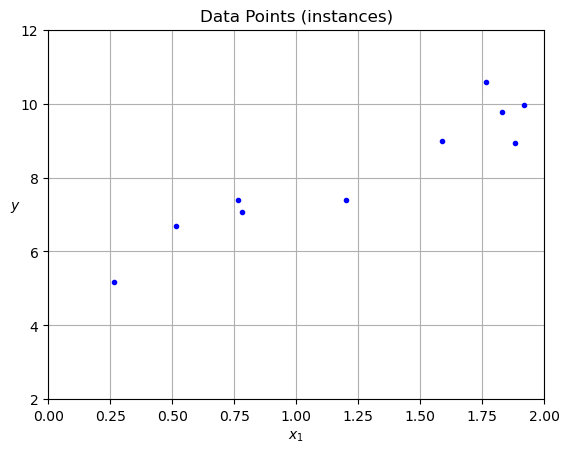

In [82]:
def plot_data_points(X, y):
    plt.plot(X, y, "b.")
    plt.xlabel("$x_1$")
    plt.ylabel("$y$", rotation=0)
    plt.title("Data Points (instances)")
    plt.axis([X_RANGE['min'], X_RANGE['max'], floor(y_range['min']), ceil(y_range['max'])])
    plt.grid()
    plt.show()
    return

plot_data_points(X, y)

### Preprocessing the Data

Now we are adding a dummy input parameter, that is equal to one for all instances: $x_0=1$.
This will allow us to use a single matrix multiplication for the equation $y =  w_0*1 + w_1*x_1$. It  is the generic form of a 1-dimensional linear equation.

(for additional optional context, see: [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.add_dummy_feature.html))

In [84]:
# we create a matrix with the shape of X and all members are 1,
# Then combine X with this matrix on the dimention of 1.
X_extended = torch.cat((torch.full(size=X.shape, fill_value=1), X), dim=1) #concatenate paranteses with X in dim=1

### Defining the Model
With this form of input we can define the parameters: $w_0$ and $w_1$.
The equation is $y = w_0*x_0 + w_1*x_1$, or in a matrix notation: $y = X @ W$.
It might be helpful to write with PyTorch.

In [86]:
def model(X, W):
    return X @ W

Let's assign values to our parameters, $W$

In [88]:
W = torch.randn((2, 1))  # shape: (2, 1)


In [89]:
def predict(X: torch.Tensor, W: torch.Tensor, is_preprocessed=False) -> torch.Tensor:
    """
    Calculates the value of a linear function with parameters W at points X.

    X: torch tensor of shape (number_of_points_to_predict, 1)
    W: torch tensor of shape (2, 1)
    return: torch tensor of shape (number_of_points_to_predict, 1)

    """
    if is_preprocessed:
        X_extended = X
    else:
        X_extended = torch.cat((torch.full(X.shape, 1), X), 1)  # preprocess
    y_predicted = model(X_extended, W)
    return y_predicted

In [90]:
y_predicted = predict(X_extended, W, is_preprocessed=True)

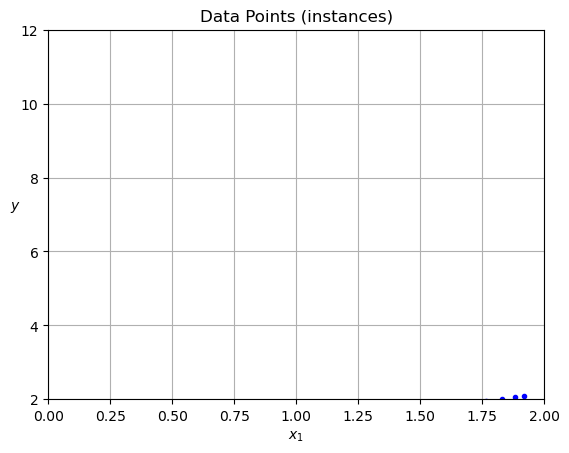

In [91]:
plot_data_points(X, y_predicted)

Let's plot the data points and the predictions (based on the initial $W$) on the same graph:

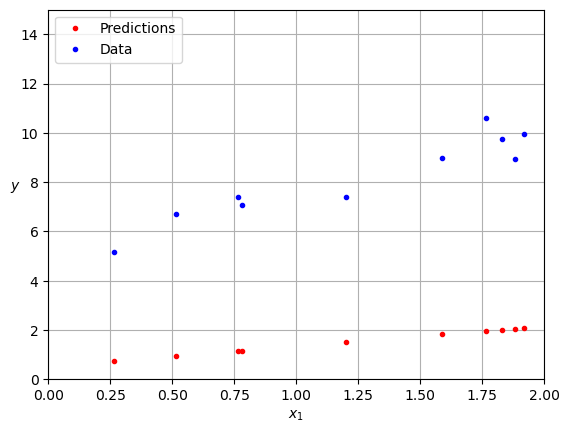

In [93]:
plt.plot(X, y_predicted, "r.", label="Predictions")
plt.plot(X, y, "b.", label="Data")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

### Setting up a Loss Function
A loss-function defines the value to be optimized (minimized).

The loss function we are going to use is the mean squared error (MSE):

$L=\frac{1}{m}*\sum_{n=1} ^{m} (y_{predicted, n} - y_n)^2$

Question: what is the difference between a MSE and Mean Absolute Error (MAE)? When would we use each? Will using MAE instead of MSE make a difference in the case of linear regression?

In [97]:
def loss(y_predicted, y):
    mse = ((y_predicted - y) ** 2).mean()  # mean squared error. This is equivalent to: torch.sum((y_predicted - y)**2)/y.numel()
    return mse

In [98]:
# First, demonstrating the calculation of the loss for each instance:
print('Squared error per instance:')
print((y_predicted - y)**2)

Squared error per instance:
tensor([[74.5522],
        [60.1358],
        [39.0718],
        [61.9563],
        [34.7987],
        [34.6450],
        [33.0112],
        [51.3226],
        [47.4256],
        [19.6335]])


In [99]:
mse = torch.sum((y_predicted - y)**2)/y.numel()
print(f'MSE: {mse:.4}')

MSE: 45.66


In [100]:
mse = loss(y_predicted, y)
print(f'MSE: {mse:.4}')

MSE: 45.66


### Optimization
Next we can manually calculate the derivative and use it for gradient descent

The cost function per instance is: $(w0 + w_1*x_1 - y)^2$
There are two partial derivatives for this equation, one for each of the two parameters:

$\frac{\partial(F)}{\partial(w_0)} = 2*(w0 + w_1*x_1 - y)$

$\frac{\partial(F)}{\partial(w_1)} = 2*(w0 + w_1*x_1 - y)*x_1$

Let's look at these equations to gain some intution. The difference between the two is the multiplciation by $x_1$ for $\frac{\partial(f)}{\partial(w_1)}$ but not for $\frac{\partial(f)}{\partial(w_0)}$. This make intuitive sense, given that as $x_1$ is larger, a change in the slope ($w_1$) would have a larger effect on `y_predicted`. A change in `w_1` for larger `x_1` results in a larger difference in the loss function value compared to a smaller `x_1`.

On the other hand, a change in `w_0` will have the same effect on the loss function value, regardless of the data (`x_1`).

This is what the gradient tell us.

In [104]:
# calculating the gradient:
d_w0 = 2*(X_extended @ W - y)
d_w1 = 2*(X_extended @ W - y) * X_extended[:, 1].reshape(-1, 1)

In [105]:
d_w0

tensor([[-17.2687],
        [-15.5095],
        [-12.5015],
        [-15.7425],
        [-11.7981],
        [-11.7720],
        [-11.4911],
        [-14.3280],
        [-13.7732],
        [ -8.8619]])

In [106]:
d_w1

tensor([[-30.4713],
        [-28.3824],
        [ -9.5727],
        [-30.2037],
        [ -9.2131],
        [-14.1475],
        [ -5.8966],
        [-22.7425],
        [-25.9150],
        [ -2.3606]])

And the _mean_ partial derivative over all instances is:

In [108]:
d_w0_mean = torch.mean(d_w0)
d_w1_mean = torch.mean(d_w1)
print(f'd_w0_mean: {d_w0_mean:.4}')
print(f'd_w1_mean: {d_w1_mean:.4}')

d_w0_mean: -13.3
d_w1_mean: -17.89


Notice that the gradient points to the direction of maximum increase of the loss function. And since the loss needs to be minimized:

* the direction that should be taken to minimize the function is opposite to the direction of the gradient.

* So the direction of gradient descent is opposite to the direction of the gradient.

Now we can define a learning rate, which is a multiplier of the gradient:

In [111]:
lr = 0.02
print(f'Learning Rate: {lr:.4}')

Learning Rate: 0.02


Let's run the first iteration, and take a look at the value of the parameters.

In [113]:
W_new = W.clone()

In [114]:
W_new[0] = W_new[0] - lr * d_w0_mean
W_new[1] = W_new[1] - lr * d_w1_mean
print(W)
print(W_new)

tensor([[0.5349],
        [0.8094]])
tensor([[0.8010],
        [1.1672]])


In [115]:
y_predicted = predict(X_extended, W_new, is_preprocessed=True)

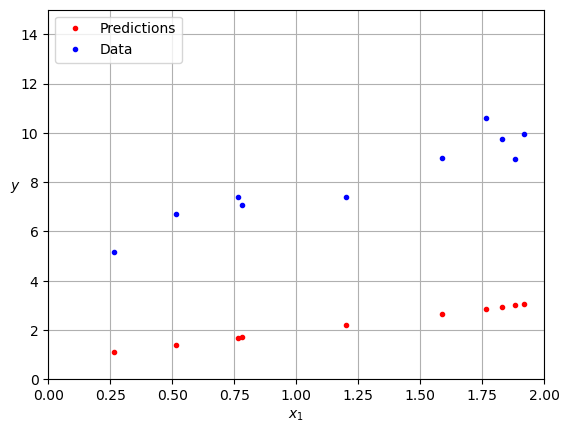

In [116]:
plt.plot(X, y_predicted, "r.", label="Predictions")
plt.plot(X, y, "b.", label="Data")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

Now let's run multiple iterations of this gradient-descent optimization process.

In [118]:
for epoch in range(25):
    y_predicted = predict(X_extended, W, is_preprocessed=True)
    mse = torch.sum((y_predicted - y)**2)/y.numel()
    d_w0_mean = torch.mean(2*(X_extended @ W - y))
    d_w1_mean = torch.mean(2*(X_extended @ W - y) * X_extended[:, 1].reshape(-1, 1))
    W[0] = W[0] - lr * d_w0_mean
    W[1] = W[1] - lr * d_w1_mean
    print(f'Epoch {epoch}: MSE: {mse:.4} W_0: {W.numpy()[0][0]:.4} W_1: {W.numpy()[1][0]:.4}')

Epoch 0: MSE: 45.66 W_0: 0.801 W_1: 1.167
Epoch 1: MSE: 36.27 W_0: 1.039 W_1: 1.484
Epoch 2: MSE: 28.86 W_0: 1.251 W_1: 1.765
Epoch 3: MSE: 23.01 W_0: 1.44 W_1: 2.014
Epoch 4: MSE: 18.39 W_0: 1.61 W_1: 2.234
Epoch 5: MSE: 14.75 W_0: 1.762 W_1: 2.429
Epoch 6: MSE: 11.87 W_0: 1.898 W_1: 2.601
Epoch 7: MSE: 9.594 W_0: 2.02 W_1: 2.753
Epoch 8: MSE: 7.798 W_0: 2.129 W_1: 2.887
Epoch 9: MSE: 6.379 W_0: 2.227 W_1: 3.006
Epoch 10: MSE: 5.258 W_0: 2.316 W_1: 3.111
Epoch 11: MSE: 4.371 W_0: 2.396 W_1: 3.203
Epoch 12: MSE: 3.67 W_0: 2.468 W_1: 3.284
Epoch 13: MSE: 3.115 W_0: 2.533 W_1: 3.355
Epoch 14: MSE: 2.676 W_0: 2.591 W_1: 3.418
Epoch 15: MSE: 2.327 W_0: 2.645 W_1: 3.473
Epoch 16: MSE: 2.051 W_0: 2.693 W_1: 3.52
Epoch 17: MSE: 1.831 W_0: 2.737 W_1: 3.562
Epoch 18: MSE: 1.656 W_0: 2.777 W_1: 3.599
Epoch 19: MSE: 1.517 W_0: 2.814 W_1: 3.63
Epoch 20: MSE: 1.405 W_0: 2.848 W_1: 3.658
Epoch 21: MSE: 1.316 W_0: 2.879 W_1: 3.681
Epoch 22: MSE: 1.244 W_0: 2.908 W_1: 3.701
Epoch 23: MSE: 1.186 W_0: 2

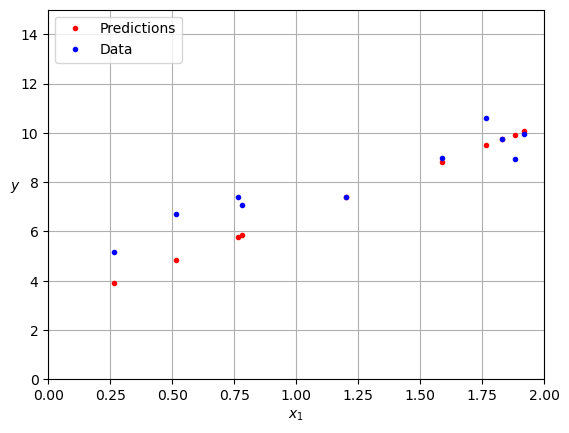

In [119]:
plt.plot(X, y_predicted, "r.", label="Predictions")
plt.plot(X, y, "b.", label="Data")

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()